# LSB Steganography - Data Embedding in Images
This notebook hides a secret message inside an image using the **Least Significant Bit (LSB)** technique.
Run each block (cell) in order, from top to bottom.


In [11]:
# ============================================================
# BLOCK 1: Install required libraries
# Run this block ONCE the first time you set up the environment
# ============================================================
import sys
!{sys.executable} -m pip install numpy opencv-python Pillow matplotlib


In [12]:
# ============================================================
# BLOCK 2: Import libraries
# ============================================================
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

print('All libraries imported successfully!')


All libraries imported successfully!


In [13]:
# ============================================================
# BLOCK 3: Constants and helper functions
# ============================================================

DELIMITER = '$$END$$'   # marks the end of the hidden message

def text_to_bits(text):
    bits = []
    for char in text:
        byte = ord(char)
        for i in range(7, -1, -1):
            bits.append((byte >> i) & 1)
    return bits

def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) < 8:
            break
        value = int(''.join(str(b) for b in byte), 2)
        chars.append(chr(value))
    return ''.join(chars)

print('Block 3 ready. DELIMITER =', repr(DELIMITER))


Block 3 ready. DELIMITER = '$$END$$'


In [14]:
# ============================================================
# BLOCK 4: Embed message - LSB method (numpy fast version)
# ============================================================

def embed_message(image_path, message, output_path):

    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f'Cannot open image: {image_path}')

    img = img.copy()
    h, w = img.shape[:2]

    full_message = message + DELIMITER
    bits = text_to_bits(full_message)
    total_bits = len(bits)
    capacity   = h * w * 3

    print(f'Image size        : {w}x{h}')
    print(f'Capacity          : {capacity} bits  ({capacity // 8} characters)')
    print(f'Bits to embed     : {total_bits}  ({len(full_message)} chars incl. delimiter)')

    if total_bits > capacity:
        raise ValueError(f'Message too long! Max: {(capacity // 8) - len(DELIMITER)} chars')

    # Flatten image, embed all bits at once, reshape back
    flat = img.flatten().astype(np.uint8)
    bits_array = np.array(bits, dtype=np.uint8)

    # Clear LSBs for the pixels we'll use, then write message bits
    flat[:total_bits] = (flat[:total_bits] & 0b11111110) | bits_array
    img = flat.reshape(h, w, 3)

    if not output_path.lower().endswith('.png'):
        output_path = output_path.rsplit('.', 1)[0] + '.png'
        print(f'Warning: output forced to PNG -> {output_path}')

    ok = cv2.imwrite(output_path, img)
    print(f'Saved: {output_path}  |  Success: {ok}')
    return img

print('embed_message() fast version defined.')

embed_message() fast version defined.


In [15]:
# ============================================================
# BLOCK 5: Extract message - LSB method (numpy fast version)
# ============================================================

def extract_message(stego_image_path):

    img = cv2.imread(stego_image_path)
    if img is None:
        raise FileNotFoundError(f'Cannot open image: {stego_image_path}')

    # Extract ALL LSBs at once using numpy (36x faster than pixel loop)
    # (img & 1) zeroes out all bits except the LSB for every channel value
    # .flatten() collapses [H, W, 3] into a single flat list of bits
    all_bits = (img & 1).flatten().tolist()

    # Now scan through bits in groups of 8 to build characters
    # and stop as soon as we find the delimiter
    text = []
    for i in range(0, len(all_bits) - 7, 8):
        byte_val = (all_bits[i]   << 7 | all_bits[i+1] << 6 |
                    all_bits[i+2] << 5 | all_bits[i+3] << 4 |
                    all_bits[i+4] << 3 | all_bits[i+5] << 2 |
                    all_bits[i+6] << 1 | all_bits[i+7])
        text.append(chr(byte_val))

        # Check for delimiter every time we add a character
        if len(text) >= len(DELIMITER) and \
           ''.join(text[-len(DELIMITER):]) == DELIMITER:
            return ''.join(text[:-len(DELIMITER)])

    return ''.join(text)

print('extract_message() fast version defined.')

extract_message() fast version defined.


In [16]:
# ============================================================
# BLOCK 6: Create a test cover image (skip if you have one)
# ============================================================

# def create_test_image(path, width=512, height=512):
#     img = np.zeros((height, width, 3), dtype=np.uint8)
#     for row in range(height):
#         for col in range(width):
#             img[row, col] = [
#                 int(col * 255 / width),
#                 int(row * 255 / height),
#                 int((row + col) * 255 / (height + width))
#             ]
#     cv2.imwrite(path, img)
#     print(f'Test image created: {path}  ({width}x{height})')

# create_test_image('cover_image.png')


In [17]:
# ============================================================
# BLOCK 7: EMBED your secret message
# --> Edit the variables below before running <--
# ============================================================

COVER_IMAGE_PATH = 'originalImg.png'    # <-- path to your cover image
SECRET_MESSAGE   = 'Hello, this is a secret message hidden with LSB and i am mustapha trying to hide that from others'
STEGO_IMAGE_PATH = 'stego_lsb.png'      # <-- output path (must be PNG)

stego = embed_message(
    image_path  = COVER_IMAGE_PATH,
    message     = SECRET_MESSAGE,
    output_path = STEGO_IMAGE_PATH
)

print('\nEmbedding complete!')


Image size        : 1313x736
Capacity          : 2899104 bits  (362388 characters)
Bits to embed     : 832  (104 chars incl. delimiter)
Saved: stego_lsb.png  |  Success: True

Embedding complete!


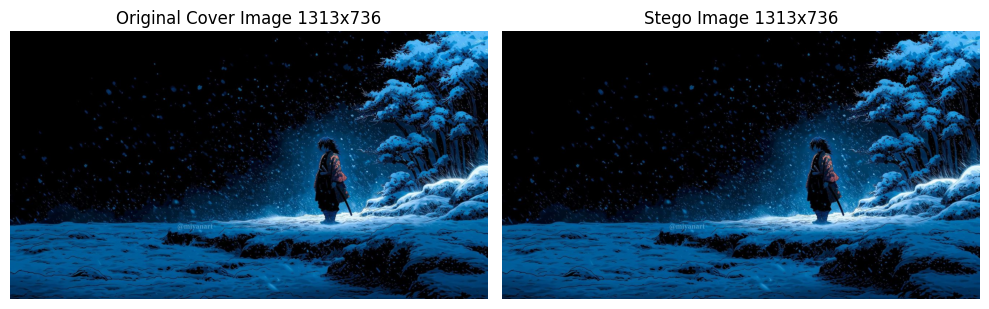

PSNR: 87.26 dB  (> 40 dB means distortion is imperceptible)


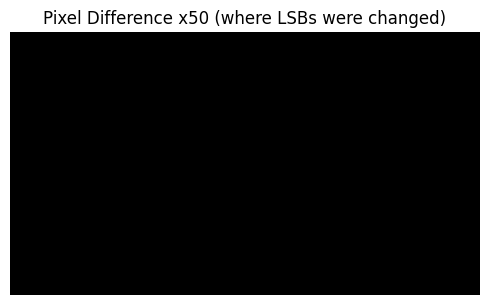

In [18]:
# ============================================================
# BLOCK 8: Visual comparison + PSNR
# ============================================================

cover         = cv2.cvtColor(cv2.imread(COVER_IMAGE_PATH), cv2.COLOR_BGR2RGB)
stego_display = cv2.cvtColor(cv2.imread(STEGO_IMAGE_PATH), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cover)
axes[0].set_title(f'Original Cover Image {cover.shape[1]}x{cover.shape[0]}')
axes[0].axis('off')
axes[1].imshow(stego_display)
axes[1].set_title(f'Stego Image {stego_display.shape[1]}x{stego_display.shape[0]}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

h, w = stego_display.shape[:2]
cover_cropped = cover[0:h, 0:w]
mse = np.mean((cover_cropped.astype(float) - stego_display.astype(float)) ** 2)
if mse == 0:
    print('PSNR: Infinity (images are identical)')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)
    print(f'PSNR: {psnr:.2f} dB  (> 40 dB means distortion is imperceptible)')

# Amplified difference heatmap
diff = np.abs(cover_cropped.astype(int) - stego_display.astype(int)).astype(np.uint8)
diff_amplified = np.clip(diff * 50, 0, 255).astype(np.uint8)
fig2, ax2 = plt.subplots(1, 1, figsize=(5, 4))
ax2.imshow(diff_amplified)
ax2.set_title('Pixel Difference x50 (where LSBs were changed)')
ax2.axis('off')
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# BLOCK 9: EXTRACT + character-by-character comparison
# ============================================================

extracted = extract_message(STEGO_IMAGE_PATH)

print(f'Original : "{SECRET_MESSAGE}"')
print(f'Extracted: "{extracted}"')
print()
print('Character by character:')
for i, (o, e) in enumerate(zip(SECRET_MESSAGE, extracted)):
    status = 'OK' if o == e else f'WRONG  expected={repr(o)} got={repr(e)}'
    print(f'  [{i:3d}] {status}')

if len(extracted) != len(SECRET_MESSAGE):
    print(f'\nLength mismatch! original={len(SECRET_MESSAGE)}, extracted={len(extracted)}')
else:
    print('\nSUCCESS: Extracted message matches the original!')


Original : "Hello, this is a secret message hidden with LSB and i am mustapha trying to hide that from others"
Extracted: "Hello, this is a secret message hidden with LSB and i am mustapha trying to hide that from others"

Character by character:
  [  0] OK
  [  1] OK
  [  2] OK
  [  3] OK
  [  4] OK
  [  5] OK
  [  6] OK
  [  7] OK
  [  8] OK
  [  9] OK
  [ 10] OK
  [ 11] OK
  [ 12] OK
  [ 13] OK
  [ 14] OK
  [ 15] OK
  [ 16] OK
  [ 17] OK
  [ 18] OK
  [ 19] OK
  [ 20] OK
  [ 21] OK
  [ 22] OK
  [ 23] OK
  [ 24] OK
  [ 25] OK
  [ 26] OK
  [ 27] OK
  [ 28] OK
  [ 29] OK
  [ 30] OK
  [ 31] OK
  [ 32] OK
  [ 33] OK
  [ 34] OK
  [ 35] OK
  [ 36] OK
  [ 37] OK
  [ 38] OK
  [ 39] OK
  [ 40] OK
  [ 41] OK
  [ 42] OK
  [ 43] OK
  [ 44] OK
  [ 45] OK
  [ 46] OK
  [ 47] OK
  [ 48] OK
  [ 49] OK
  [ 50] OK
  [ 51] OK
  [ 52] OK
  [ 53] OK
  [ 54] OK
  [ 55] OK
  [ 56] OK
  [ 57] OK
  [ 58] OK
  [ 59] OK
  [ 60] OK
  [ 61] OK
  [ 62] OK
  [ 63] OK
  [ 64] OK
  [ 65] OK
  [ 66] OK
  [ 67] OK
  [ 6

In [20]:
# ============================================================
# BLOCK 10: Attack functions
# ============================================================

def calc_psnr(img1_path, img2_path):
    a = cv2.imread(img1_path).astype(np.float64)
    b = cv2.imread(img2_path).astype(np.float64)
    h = min(a.shape[0], b.shape[0])
    w = min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255 ** 2) / mse)

def evaluate(extracted, original):
    total = len(original)
    if not extracted:
        return False, total, total
    corrupted = sum(1 for a, b in zip(original, extracted) if a != b)
    corrupted += abs(len(original) - len(extracted))
    return (corrupted == 0), corrupted, total

# ATTACK 1: JPEG Compression - re-quantizes pixels, destroys LSBs
def attack_jpeg(stego_path, quality, output_path):
    img = cv2.imread(stego_path)
    temp_jpg = output_path.replace('.png', '_temp.jpg')
    cv2.imwrite(temp_jpg, img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    reloaded = cv2.imread(temp_jpg)
    cv2.imwrite(output_path, reloaded)
    os.remove(temp_jpg)
    return output_path

# ATTACK 2: Gaussian Noise - random pixel flips destroy LSBs
def attack_gaussian_noise(stego_path, std, output_path):
    img = cv2.imread(stego_path).astype(np.float64)
    noise = np.random.normal(0, std, img.shape)
    noisy = np.clip(img + noise, 0, 255).astype(np.uint8)
    cv2.imwrite(output_path, noisy)
    return output_path

# ATTACK 3: Resize - interpolation scrambles all pixel values
def attack_resize(stego_path, scale_factor, output_path):
    img = cv2.imread(stego_path)
    h, w = img.shape[:2]
    small    = cv2.resize(img, (int(w * scale_factor), int(h * scale_factor)), interpolation=cv2.INTER_LINEAR)
    restored = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(output_path, restored)
    return output_path

# ATTACK 4: Rotation - even 1 degree changes every pixel
def attack_rotation(stego_path, angle, output_path):
    img = cv2.imread(stego_path)
    h, w = img.shape[:2]
    center   = (w // 2, h // 2)
    M_fwd    = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated  = cv2.warpAffine(img, M_fwd,  (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    M_back   = cv2.getRotationMatrix2D(center, -angle, 1.0)
    restored = cv2.warpAffine(rotated, M_back, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    cv2.imwrite(output_path, restored)
    return output_path

# ATTACK 6: Median Filter - smoothing replaces pixels with neighborhood medians
def attack_median_filter(stego_path, kernel_size, output_path):
    img = cv2.imread(stego_path)
    cv2.imwrite(output_path, cv2.medianBlur(img, kernel_size))
    return output_path

print('All attack functions defined.')


All attack functions defined.


In [21]:
# ============================================================
# BLOCK 11: Run all attacks and collect results
# ============================================================

import gc

# Free any leftover large variables from previous runs
import gc
gc.collect()

# Also clear the stego array from Block 7 if it's still in memory
try:
    del stego
except: pass

ATTACK_DIR = 'attacked_images_lsb'
os.makedirs(ATTACK_DIR, exist_ok=True)

attacks = [
    ('JPEG Quality=90',       lambda: attack_jpeg(STEGO_IMAGE_PATH, 90,  f'{ATTACK_DIR}/jpeg_q90.png')),
    ('JPEG Quality=75',       lambda: attack_jpeg(STEGO_IMAGE_PATH, 75,  f'{ATTACK_DIR}/jpeg_q75.png')),
    ('JPEG Quality=50',       lambda: attack_jpeg(STEGO_IMAGE_PATH, 50,  f'{ATTACK_DIR}/jpeg_q50.png')),
    ('Gaussian Noise std=1',  lambda: attack_gaussian_noise(STEGO_IMAGE_PATH, 1,  f'{ATTACK_DIR}/noise_1.png')),
    ('Gaussian Noise std=5',  lambda: attack_gaussian_noise(STEGO_IMAGE_PATH, 5,  f'{ATTACK_DIR}/noise_5.png')),
    ('Gaussian Noise std=15', lambda: attack_gaussian_noise(STEGO_IMAGE_PATH, 15, f'{ATTACK_DIR}/noise_15.png')),
    ('Resize scale=0.9',      lambda: attack_resize(STEGO_IMAGE_PATH, 0.9,  f'{ATTACK_DIR}/resize_90.png')),
    ('Resize scale=0.75',     lambda: attack_resize(STEGO_IMAGE_PATH, 0.75, f'{ATTACK_DIR}/resize_75.png')),
    ('Resize scale=0.5',      lambda: attack_resize(STEGO_IMAGE_PATH, 0.5,  f'{ATTACK_DIR}/resize_50.png')),
    ('Rotation 1 deg',        lambda: attack_rotation(STEGO_IMAGE_PATH, 1,  f'{ATTACK_DIR}/rot_1.png')),
    ('Rotation 5 deg',        lambda: attack_rotation(STEGO_IMAGE_PATH, 5,  f'{ATTACK_DIR}/rot_5.png')),
    ('Rotation 10 deg',       lambda: attack_rotation(STEGO_IMAGE_PATH, 10, f'{ATTACK_DIR}/rot_10.png')),
    ('Median Filter k=3',     lambda: attack_median_filter(STEGO_IMAGE_PATH, 3, f'{ATTACK_DIR}/median_3.png')),
    ('Median Filter k=5',     lambda: attack_median_filter(STEGO_IMAGE_PATH, 5, f'{ATTACK_DIR}/median_5.png')),
]

results = []
print(f'Running {len(attacks)} attacks...\n')
print(f'{"Attack":<25} {"Survived":<10} {"Corrupted":<15} {"PSNR (dB)":<12}')
print('-' * 65)

for attack_name, attack_fn in attacks:
    try:
        attacked_path = attack_fn()
        extracted     = extract_message(attacked_path)
        survived, corrupted, total = evaluate(extracted, SECRET_MESSAGE)
        psnr     = calc_psnr(STEGO_IMAGE_PATH, attacked_path)
        psnr_str = f'{psnr:.2f}' if psnr != float('inf') else 'inf'
        results.append({'name': attack_name, 'survived': survived, 'corrupted': corrupted,
                        'total': total, 'psnr': psnr, 'psnr_str': psnr_str,
                        'extracted': extracted, 'path': attacked_path})
        status = 'YES v' if survived else 'NO  x'
        print(f'{attack_name:<25} {status:<10} {corrupted}/{total} chars      {psnr_str:<12}')
    except Exception as e:
        print(f'{attack_name:<25} ERROR: {e}')
        results.append({'name': attack_name, 'survived': False, 'corrupted': -1,
                        'total': len(SECRET_MESSAGE), 'psnr': 0, 'psnr_str': 'N/A',
                        'extracted': '', 'path': ''})
    finally:
        gc.collect()

print('-' * 65)
print(f'\nMessage survived {sum(1 for r in results if r["survived"])}/{len(results)} attacks.')


Running 14 attacks...

Attack                    Survived   Corrupted       PSNR (dB)   
-----------------------------------------------------------------
JPEG Quality=90           NO  x      362388/97 chars      43.81       
JPEG Quality=75           NO  x      362388/97 chars      38.92       
JPEG Quality=50           NO  x      362388/97 chars      32.42       
Gaussian Noise std=1      NO  x      362386/97 chars      48.55       
Gaussian Noise std=5      NO  x      362388/97 chars      35.58       
Gaussian Noise std=15     NO  x      362388/97 chars      26.22       
Resize scale=0.9          NO  x      362316/97 chars      34.23       
Resize scale=0.75         NO  x      362347/97 chars      32.98       
Resize scale=0.5          NO  x      362379/97 chars      30.45       
Rotation 1 deg            NO  x      362335/97 chars      33.91       
Rotation 5 deg            NO  x      362330/97 chars      26.93       
Rotation 10 deg           NO  x      362340/97 chars      23.26 